In [1]:
# Import libraries
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import medmnist
from medmnist import PathMNIST

print('TensorFlow version:', tf.__version__)
print('Keras version:', keras.__version__)

2025-11-25 15:43:52.855613: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow version: 2.20.0
Keras version: 3.12.0


## 1. Data Acquisition

PathMNIST: 9-class histology dataset (28x28 RGB images) from colon tissue patches.

In [2]:
# Download PathMNIST
train_dataset = PathMNIST(split='train', download=True, root='../data/')
val_dataset = PathMNIST(split='val', download=True, root='../data/')
test_dataset = PathMNIST(split='test', download=True, root='../data/')

info = medmnist.INFO['pathmnist']
print(f"Dataset: {info['task']}")
print(f"Train samples: {len(train_dataset)}")
print(f"Val samples: {len(val_dataset)}")
print(f"Test samples: {len(test_dataset)}")
print(f"Classes: {info['label']}")

Dataset: multi-class
Train samples: 89996
Val samples: 10004
Test samples: 7180
Classes: {'0': 'adipose', '1': 'background', '2': 'debris', '3': 'lymphocytes', '4': 'mucus', '5': 'smooth muscle', '6': 'normal colon mucosa', '7': 'cancer-associated stroma', '8': 'colorectal adenocarcinoma epithelium'}


## 2. Exploratory Data Analysis

### Feature 1: Class Distribution

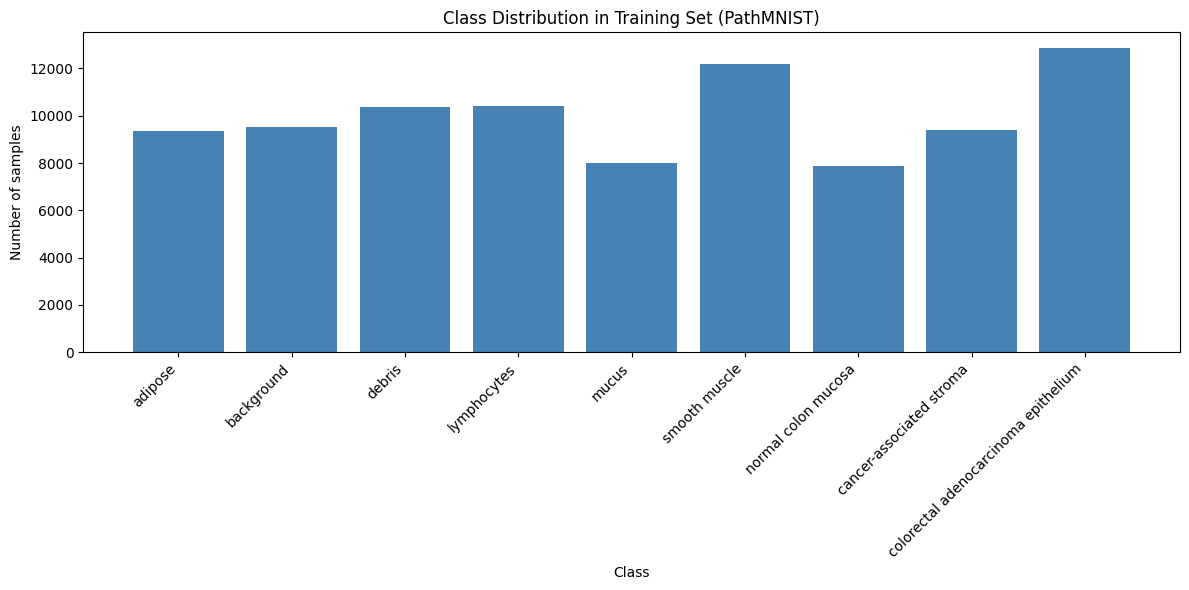

adipose: 9366 samples
background: 9509 samples
debris: 10360 samples
lymphocytes: 10401 samples
mucus: 8006 samples
smooth muscle: 12182 samples
normal colon mucosa: 7886 samples
cancer-associated stroma: 9401 samples
colorectal adenocarcinoma epithelium: 12885 samples


In [3]:
# Class distribution in train set
train_labels = [train_dataset[i][1].item() for i in range(len(train_dataset))]
unique, counts = np.unique(train_labels, return_counts=True)

class_names = list(info['label'].values())
plt.figure(figsize=(12, 6))
plt.bar(unique, counts, color='steelblue')
plt.xlabel('Class')
plt.ylabel('Number of samples')
plt.title('Class Distribution in Training Set (PathMNIST)')
plt.xticks(unique, class_names, rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../data/samples/class_distribution.png', dpi=150)
plt.show()

for cls, cnt in zip(unique, counts):
    print(f"{class_names[cls]}: {cnt} samples")

**Interpretation**: The dataset is moderately balanced with classes ranging from ~8k to ~13k samples. Smooth muscle and colorectal adenocarcinoma have the highest representation.

### Feature 2: Sample Images

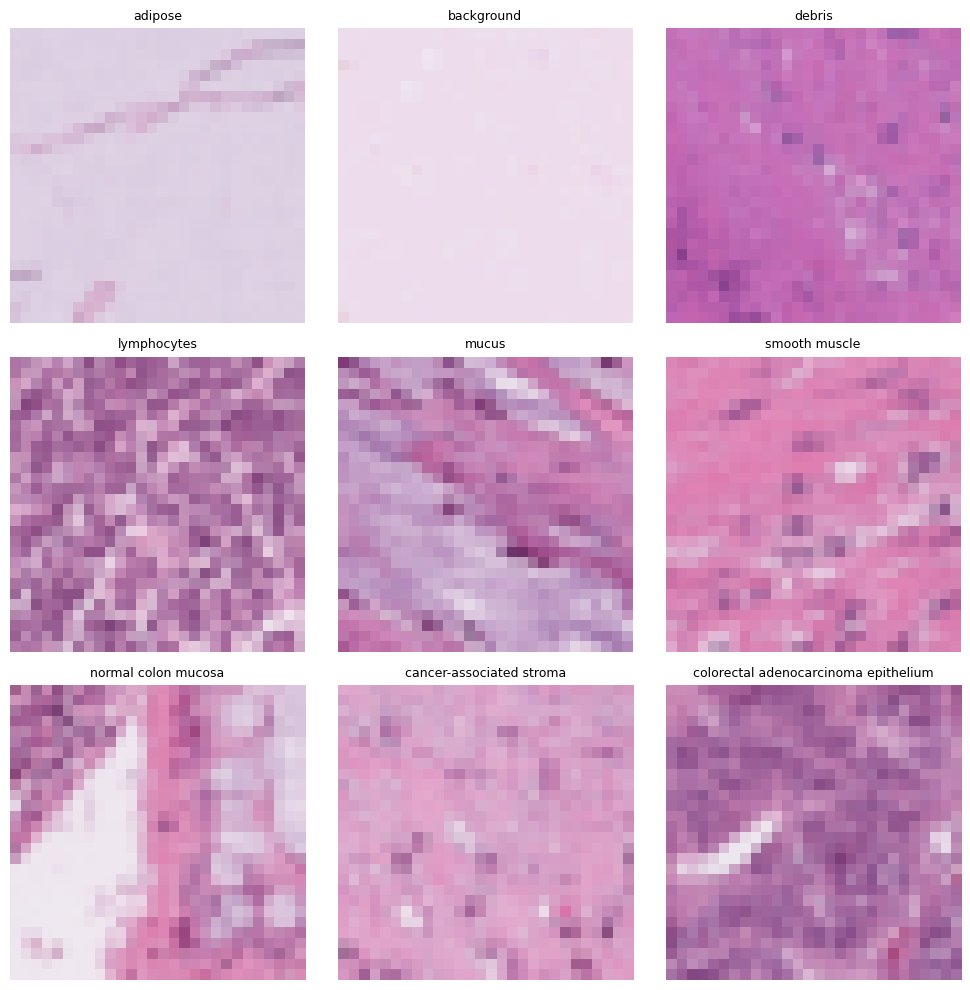

In [4]:
# Display sample images per class
fig, axes = plt.subplots(3, 3, figsize=(10, 10))
for i in range(9):
    idx = np.where(np.array(train_labels) == i)[0][0]
    img, lbl = train_dataset[idx]
    ax = axes[i // 3, i % 3]
    ax.imshow(img)
    ax.set_title(class_names[i], fontsize=9)
    ax.axis('off')
plt.tight_layout()
plt.savefig('../data/samples/sample_images_grid.png', dpi=150)
plt.show()

**Interpretation**: Images are 28x28 RGB histology patches showing distinct tissue textures and colors for each class.

### Feature 3: Image Size and Channels

In [5]:
# Check image shape
sample_img, _ = train_dataset[0]
print(f"Image shape: {np.array(sample_img).shape}")
print(f"Image type: {type(sample_img)}")
print(f"Pixel value range: [{np.array(sample_img).min()}, {np.array(sample_img).max()}]")

Image shape: (28, 28, 3)
Image type: <class 'PIL.Image.Image'>
Pixel value range: [164, 228]


**Interpretation**: Images are 28x28 RGB (3 channels), small resolution but sufficient for transfer learning with upscaling.

## 3. Data Preprocessing

Convert MedMNIST datasets to TensorFlow format, resize to 96x96 for transfer learning, and normalize.

In [ ]:
def medmnist_to_tf(dataset, batch_size=32, target_size=(96, 96)):
    """Convert MedMNIST dataset to TensorFlow dataset."""
    images = []
    labels = []
    for img, lbl in dataset:
        img_array = np.array(img).astype('float32') / 255.0
        images.append(img_array)
        labels.append(lbl.item())
    images = np.array(images)
    labels = np.array(labels)
    # Resize images
    images_resized = tf.image.resize(images, target_size).numpy()
    # One-hot encode labels
    labels_onehot = tf.keras.utils.to_categorical(labels, num_classes=9)
    ds = tf.data.Dataset.from_tensor_slices((images_resized, labels_onehot))
    ds = ds.shuffle(1000).batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

train_tf = medmnist_to_tf(train_dataset, batch_size=32)
val_tf = medmnist_to_tf(val_dataset, batch_size=32)
test_tf = medmnist_to_tf(test_dataset, batch_size=32)

print('TensorFlow datasets ready')

2025-11-25 15:44:45.152049: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
2025-11-25 15:44:45.264994: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 9952837632 exceeds 10% of free system memory.


## 4. Model Creation

Using MobileNetV2 pretrained on ImageNet as feature extractor (transfer learning) with a custom classifier head.

In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

def build_model(num_classes=9, input_shape=(96, 96, 3)):
    base = MobileNetV2(weights='imagenet', include_top=False, input_shape=input_shape)
    base.trainable = False  # Freeze base
    x = layers.GlobalAveragePooling2D()(base.output)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    model = models.Model(inputs=base.input, outputs=outputs)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
    )
    return model

model = build_model()
model.summary()

## 5. Model Training

Train with early stopping and model checkpointing (optimization techniques).

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

Path('../models').mkdir(exist_ok=True)

callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True, monitor='val_loss'),
    ModelCheckpoint('../models/model.h5', save_best_only=True, monitor='val_accuracy')
]

history = model.fit(
    train_tf,
    epochs=15,
    validation_data=val_tf,
    callbacks=callbacks
)

print('Training complete!')

## 6. Model Evaluation

Compute metrics: accuracy, precision, recall, F1-score, confusion matrix.

In [ ]:
# Predict on test set
y_true = []
y_pred = []
y_prob = []

for x, y in test_tf:
    preds = model.predict(x, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(np.argmax(y.numpy(), axis=1))
    y_prob.extend(preds)

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_prob = np.array(y_prob)

# Classification report
report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
print(classification_report(y_true, y_pred, target_names=class_names))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.savefig('../data/samples/confusion_matrix.png', dpi=150)
plt.show()

# Metrics summary
print(f"Accuracy: {report['accuracy']:.4f}")
print(f"Macro Avg Precision: {report['macro avg']['precision']:.4f}")
print(f"Macro Avg Recall: {report['macro avg']['recall']:.4f}")
print(f"Macro Avg F1-Score: {report['macro avg']['f1-score']:.4f}")

## 7. Training History Visualization

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'], label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Training and Validation Accuracy')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history.history['loss'], label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Val Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_title('Training and Validation Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('../data/samples/training_history.png', dpi=150)
plt.show()

## 8. Save class labels for prediction

Save class names for use in the API prediction module.

In [ ]:
with open('../models/classes.txt', 'w') as f:
    f.write('\n'.join(class_names))
print('Class labels saved to models/classes.txt')

## Summary

- **Dataset**: PathMNIST (9-class histology images, 89,996 train, 10,004 val, 7,180 test)
- **Preprocessing**: Resize 28x28 → 96x96, normalize to [0,1]
- **Model**: MobileNetV2 transfer learning with custom classifier
- **Optimization**: Early stopping, dropout, Adam optimizer
- **Metrics**: Accuracy, Precision, Recall, F1-score, Confusion Matrix
- **Model saved**: `models/model.h5`